In [ ]:
import pandas as pd
data=pd.read_csv("/content/drive/MyDrive/Google AI Studio/nav_history_clean.csv")
data["date"]=pd.to_datetime(data["date"])
data=data.sort_values(["amfi_code","date"])


In [ ]:
data["daily"]=(data.groupby("amfi_code")["nav"].pct_change())

In [ ]:
print(data[["amfi_code","date","nav","daily"]].head(5))

    amfi_code       date       nav     daily
17     100016 2022-01-03  520.4608       NaN
25     100016 2022-01-04  515.0971 -0.010306
34     100016 2022-01-05  521.7239  0.012865
42     100016 2022-01-06  515.7880 -0.011377
50     100016 2022-01-07  515.1639 -0.001210


In [ ]:
print(data["daily"].describe())

count    45922.000000
mean         0.000632
std          0.010292
min         -0.058102
25%         -0.005044
50%          0.000341
75%          0.006326
max          0.064713
Name: daily, dtype: float64


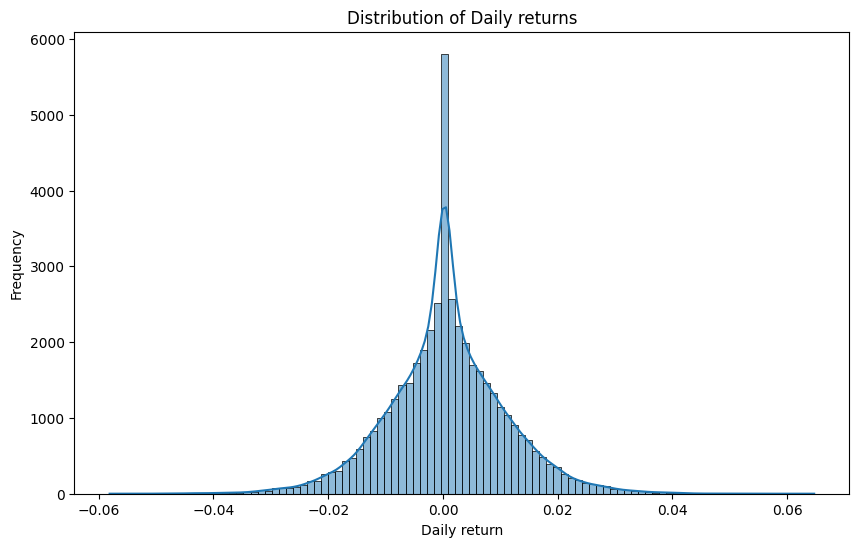

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.histplot(
    data["daily"].dropna(),
    bins=100,
    kde=True
)
plt.title("Distribution of Daily returns")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import pandas as pd
nav=pd.read_csv("/content/drive/MyDrive/Google AI Studio/nav_history_clean.csv")
nav["date"]=pd.to_datetime(nav["date"])
nav=nav.sort_values(["amfi_code","date"])
def cagr(nav_start,nav_end,years):
  if(pd.isna(nav_start)or pd.isna(nav_end)):
    return None
  if nav_start<=0:
     return None

  return ((nav_end/nav_start)**(1/years)-1)*100

In [ ]:
results=[]
for amfi_code,group in nav.groupby("amfi_code"):
  group=group.sort_values("date")
  latest_date=group["date"].max()
  latest_nav=nav.iloc[-1]["nav"]
  row={
      "amfi_code":amfi_code
  }
  for years in[1,3,5]:
    start_date=latest_date-pd.DateOffset(years=years)
    past_data=group[group["date"]<=start_date]
    if(len(past_data)==0):
      row["f{years}yr_cagr"]=cagr(start_nav,latest_nav,years)
    else:
       start_nav=past_data.iloc[-1]["nav"]
       row[f"{years}yr_cagr"]=cagr(start_nav,latest_nav,years)

    results.append(row)



In [ ]:
cagr_table = pd.DataFrame(results)

print(cagr_table.head())

   amfi_code    1yr_cagr    3yr_cagr  f{years}yr_cagr
0     100016  -53.131703  -20.726634       -13.008588
1     100016  -53.131703  -20.726634       -13.008588
2     100016  -53.131703  -20.726634       -13.008588
3     100025  809.901708  114.329700        57.997208
4     100025  809.901708  114.329700        57.997208


In [ ]:
fund=pd.read_csv("/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv")
cagr_table=cagr_table.merge(fund[["amfi_code","scheme_name"]],on="amfi_code",how="left")

In [ ]:
cagr_table = cagr_table.rename(
    columns={
        "f{years}yr_cagr": "5yr_cagr"
    }
)

print(cagr_table.columns.tolist())

['amfi_code', '1yr_cagr', '3yr_cagr', '5yr_cagr', 'scheme_name']


In [ ]:
print(cagr_table.columns.tolist())

['amfi_code', '1yr_cagr', '3yr_cagr', '5yr_cagr', 'scheme_name']


In [ ]:
top_5_yr=(
    cagr_table.sort_values(
        "5yr_cagr",
        ascending=False
    )
)
print(top_5_yr[["scheme_name","5yr_cagr"]].head(10))

                                           scheme_name   5yr_cagr
3         HDFC Short Term Debt Fund - Regular - Growth  57.997208
4         HDFC Short Term Debt Fund - Regular - Growth  57.997208
5         HDFC Short Term Debt Fund - Regular - Growth  57.997208
47                Axis Bluechip Fund - Direct - Growth  53.220875
45                Axis Bluechip Fund - Direct - Growth  53.220875
46                Axis Bluechip Fund - Direct - Growth  53.220875
39   Nippon India Gilt Securities Fund - Regular - ...  52.818522
40   Nippon India Gilt Securities Fund - Regular - ...  52.818522
41   Nippon India Gilt Securities Fund - Regular - ...  52.818522
110      Mirae Asset Tax Saver Fund - Regular - Growth  43.896999


In [ ]:
cagr_table.to_csv(
    "/content/drive/MyDrive/Google AI Studio/cagr_comparison_table.csv",
    index=False
)

In [ ]:
print(
    cagr_table[
        ["1yr_cagr",
         "3yr_cagr",
         "5yr_cagr"]
    ].describe()
)

         1yr_cagr    3yr_cagr    5yr_cagr
count  120.000000  120.000000  120.000000
mean   143.367517   36.647508   19.422602
std    204.241323   37.523448   20.557791
min    -92.979576  -56.982499  -39.718076
25%     -5.462661   12.744038    7.460675
50%     75.269011   36.620162   20.589326
75%    211.403280   62.012561   33.576151
max    809.901708  114.329700   57.997208


In [ ]:
import pandas as pd
import numpy as np
sharpe=pd.read_csv("/content/drive/MyDrive/Google AI Studio/nav_history_clean.csv")
sharpe["date"]=pd.to_datetime(sharpe["date"])
sharpe=sharpe.sort_values(["amfi_code","date"])
sharpe["daily"]=sharpe.groupby("amfi_code")["nav"].pct_change()
rf_annual=0.065
rf_Daily=rf_annual/252



In [ ]:
results=[]
for amfi_code,group in sharpe.groupby("amfi_code"):
  returns=group["daily"].dropna()
  if(len(returns)<2):
   continue
  mean_return=returns.mean()
  std_return=returns.std()
  sharpe_ratio=np.sqrt(252)*(mean_return-rf_Daily)/std_return
  results.append(
        {
            "amfi_code": amfi_code,
            "avg_daily_return": mean_return,
            "volatility": std_return,
            "sharpe_ratio": sharpe_ratio
        }
    )

In [ ]:
sharpe_table=pd.DataFrame(results)
fund=pd.read_csv("/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv")
sharpe_table=sharpe_table.merge(fund[["amfi_code","scheme_name"]],on="amfi_code",how="left")

In [ ]:
sharpe_rank = ( sharpe_table.sort_values("sharpe_ratio",ascending=False)
)
print(
    sharpe_rank[
        ["scheme_name", "sharpe_ratio"]
    ].head(10)
)

                                          scheme_name  sharpe_ratio
34      Mirae Asset Large Cap Fund - Regular - Growth      1.448291
30             Kotak Flexicap Fund - Regular - Growth      1.307820
36      Mirae Asset Tax Saver Fund - Regular - Growth      1.235808
19          SBI Bluechip Fund - Regular Plan - Growth      1.209883
25           ICICI Pru Midcap Fund - Regular - Growth      1.180101
38                 DSP Midcap Fund - Regular - Growth      1.132122
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...      1.093699
9      Nippon India Large Cap Fund - Regular - Growth      1.081659
3       ABSL Frontline Equity Fund - Regular - Growth      1.027213
24          ICICI Pru Bluechip Fund - Direct - Growth      1.026524


In [ ]:
sharpe_rank.to_csv("fund_sharpe_ranking.csv",index=False)

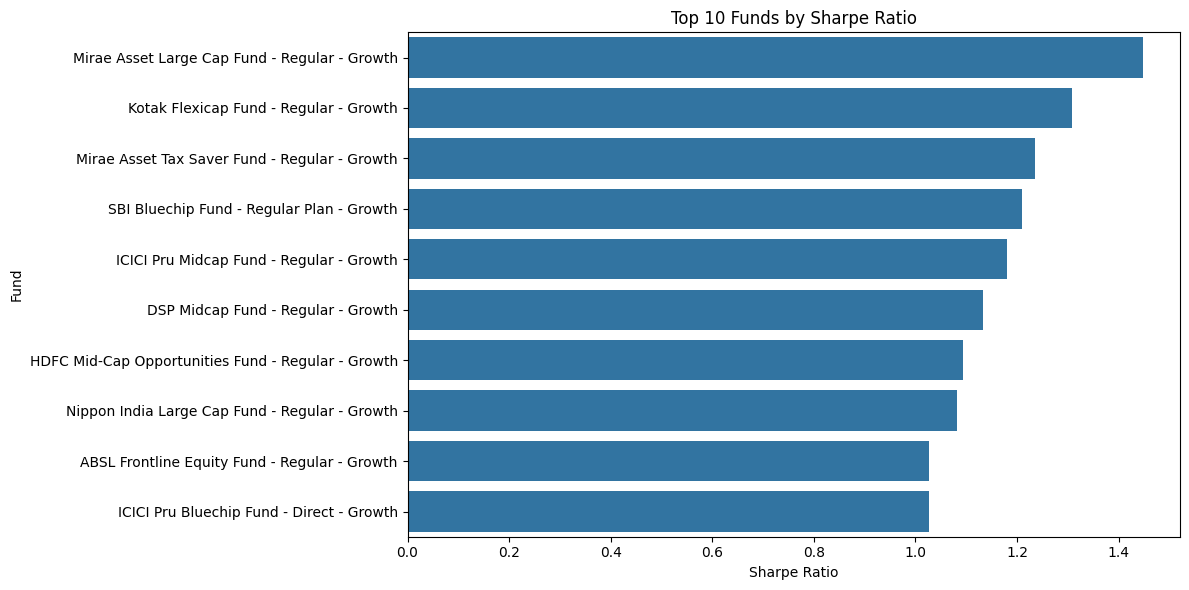

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = sharpe_rank.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.xlabel("Sharpe Ratio")
plt.ylabel("Fund")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/nav_history_clean.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [ ]:
rf_annual=0.065
rf_daily=rf_annual/252

In [ ]:
results=[]
for amfi_code,group in nav.groupby("amfi_code"):

   returns= group["daily"].dropna()

   if len(returns)<2:
      continue

mean=returns.mean()

downside_returns=returns[returns<rf_daily]
if(len(downside_returns)==0):
    std=nap.nan
else:
    std=downside_returns.std()
sortino=((mean-rf_daily)/std)*np.sqrt(252)
results.append(
    {
        "amfi_code":amfi_code,
        "avg_return": mean,
       "downside_std": std,
         "sortino_ratio":sortino
    }
)




In [ ]:
sortino_table = pd.DataFrame(results)

In [ ]:
fund=pd.read_csv("/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv")
sortino_table=sortino_table.merge(
    fund[["amfi_code","scheme_name"]],
     on="amfi_code",
    how="left"
)

In [ ]:
sortino_rank=(sortino_table.sort_values("sortino_ratio",ascending=False))
print(
    sortino_rank[
        ["scheme_name", "sortino_ratio"]
    ].head(10)
)

                             scheme_name  sortino_ratio
0  DSP Small Cap Fund - Regular - Growth       1.607125


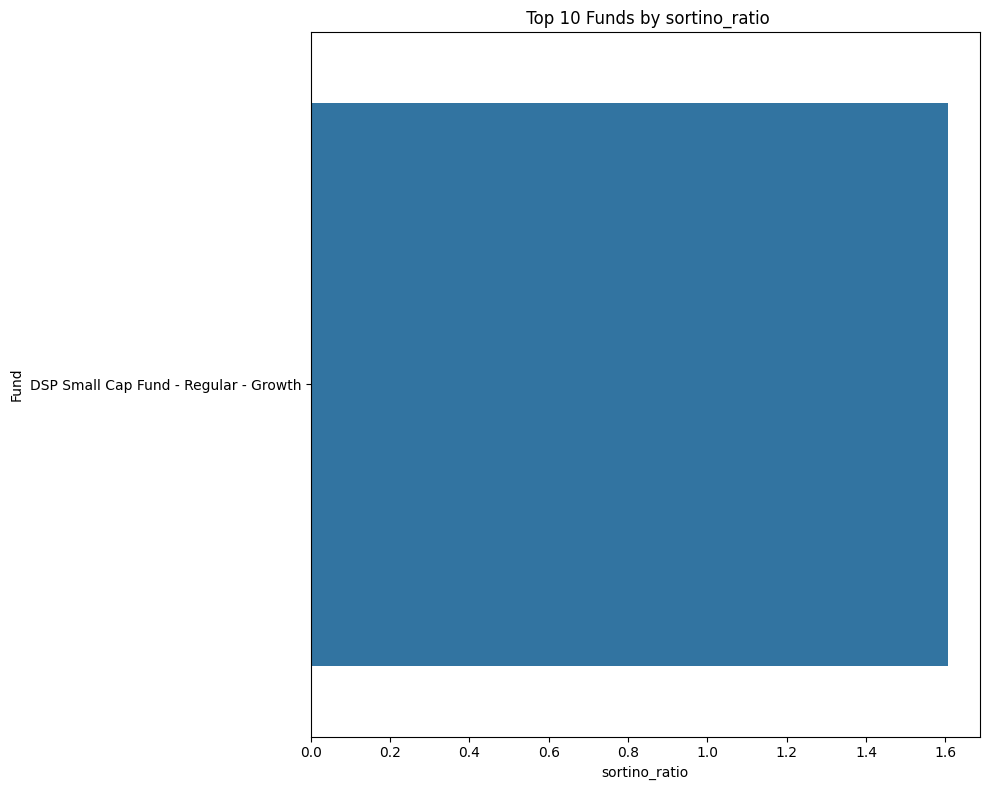

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
top=sortino_rank.head(10)
plt.figure(figsize=(10,8))
sns.barplot(
    data=top,
    x="sortino_ratio",
    y="scheme_name"
)
plt.title(" Top 10 Funds by sortino_ratio")
plt.xlabel("sortino_ratio")
plt.ylabel("Fund")
plt.tight_layout()
plt.show()

In [ ]:
print(sortino_rank.columns)
print(sortino_rank.shape)
print(sortino_rank.head(20))

Index(['amfi_code', 'avg_return', 'downside_std', 'sortino_ratio',
       'scheme_name'],
      dtype='object')
(1, 5)
   amfi_code  avg_return  downside_std  sortino_ratio  \
0     149324    0.001194      0.009248       1.607125   

                             scheme_name  
0  DSP Small Cap Fund - Regular - Growth  


In [ ]:
sortino_rank.to_csv(
    "/content/drive/MyDrive/Google AI Studio/sortino_ranking.csv",
    index=False
)

In [ ]:
nav.to_csv(
    "/content/drive/MyDrive/Google AI Studio/nav_with_returns.csv",
    index=False
)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
nav=pd.read_csv("/content/drive/MyDrive/Google AI Studio/nav_history_clean.csv")
nav["date"]=pd.to_datetime(nav["date"])


In [ ]:
nav=nav.sort_values(["amfi_code","date"])
nav["daily"]=nav.groupby("amfi_code")["nav"].pct_change()


In [ ]:
fund=pd.read_csv("/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv")
print(fund[fund["scheme_name"].str.contains("Nifty",case=False,na=False)]
[["amfi_code","scheme_name"]])

    amfi_code                                 scheme_name
18     118635              Nippon India ETF Nifty 50 BeES
31     102885  UTI Nifty 50 Index Fund - Regular - Growth


In [ ]:
benchmark=(nav[nav["amfi_code"]==102885][["date","daily"]].rename(columns={"daily":"benchmark_return"}))

In [ ]:
results=[]
for amfi_code,group in nav.groupby("amfi_code"):
  merged=group.merge(
      benchmark,
      on="date",
      how="inner"
  )
  merged=merged.dropna()
  if len(merged)<30:
   continue
slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily"]
    )
beta = slope

alpha = intercept * 252

results.append(
        {
            "amfi_code": amfi_code,
            "alpha": alpha,
            "beta": beta,
            "r_squared": r_value**2
        }
    )


In [ ]:
alpha_beta = pd.DataFrame(results)

In [ ]:
fund = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv"
)

alpha_beta = alpha_beta.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

In [ ]:
top_alpha = (
    alpha_beta
    .sort_values(
        "alpha",
        ascending=False
    )
)

print(
    top_alpha[
        ["scheme_name","alpha","beta"]
    ].head(10)
)

                             scheme_name     alpha      beta
0  DSP Small Cap Fund - Regular - Growth  0.300149  0.004602


In [ ]:
alpha_beta.to_csv(
    "/content/drive/MyDrive/Google AI Studio/alpha_beta_table.csv",
    index=False
)

In [ ]:
import pandas as pd

nav = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/nav_history_clean.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [ ]:
nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

In [ ]:
nav["drawdown"] = (
    nav["nav"]
    /
    nav["running_max"]
    - 1
)

In [ ]:
mdd_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    min_idx = group["drawdown"].idxmin()

    worst_row = group.loc[min_idx]

    mdd_results.append(
        {
            "amfi_code": amfi_code,
            "max_drawdown": worst_row["drawdown"],
            "worst_date": worst_row["date"]
        }
    )

In [ ]:
mdd_table = pd.DataFrame(
    mdd_results
)

In [ ]:
mdd_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.copy()

    trough_idx = group["drawdown"].idxmin()

    trough_row = group.loc[trough_idx]

    trough_date = trough_row["date"]

    peak_nav = trough_row["running_max"]

    peak_rows = group[
        (group["date"] <= trough_date)
        &
        (group["nav"] == peak_nav)
    ]

    peak_date = peak_rows.iloc[0]["date"]

    mdd_results.append(
        {
            "amfi_code": amfi_code,
            "max_drawdown":
                trough_row["drawdown"],
            "peak_date":
                peak_date,
            "trough_date":
                trough_date
        }
    )

In [ ]:
fund = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv"
)

mdd_table = mdd_table.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

In [ ]:
worst_drawdowns = (
    mdd_table
    .sort_values(
        "max_drawdown"
    )
)

In [ ]:
worst_drawdowns = (
    mdd_table
    .sort_values(
        "max_drawdown"
    )
)

In [ ]:
mdd_table.to_csv(
    "/content/drive/MyDrive/Google AI Studio/max_drawdown_table.csv",
    index=False
)

In [ ]:
top5_codes = (
    sharpe_rank
    .head(5)["amfi_code"]
    .tolist()
)

In [ ]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [ ]:
nifty_fund=fund[fund["scheme_name"].str.contains("Nifty|Index||ETF|BeES",case=False,na=False,regex=True)]
print(
    nifty_fund[
        ["amfi_code", "scheme_name"]
    ].to_string(index=False)
)

 amfi_code                                           scheme_name
    119551             SBI Bluechip Fund - Regular Plan - Growth
    119552              SBI Bluechip Fund - Direct Plan - Growth
    119598            SBI Small Cap Fund - Regular Plan - Growth
    119599             SBI Small Cap Fund - Direct Plan - Growth
    119120          SBI Magnum Gilt Fund - Regular Plan - Growth
    100016             HDFC Top 100 Fund - Regular Plan - Growth
    125497              HDFC Top 100 Fund - Direct Plan - Growth
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth
    125498     HDFC Mid-Cap Opportunities Fund - Direct - Growth
    100025          HDFC Short Term Debt Fund - Regular - Growth
    120503            ICICI Pru Bluechip Fund - Regular - Growth
    120504             ICICI Pru Bluechip Fund - Direct - Growth
    120505              ICICI Pru Midcap Fund - Regular - Growth
    120506     ICICI Pru Value Discovery Fund - Regular - Growth
    120507              I

In [ ]:
nifty50 = (
    nav[
        nav["amfi_code"] == 102885
    ][["date","daily_return"]]
    .rename(
        columns={
            "daily_return":"nifty50_return"
        }
    )
)

In [ ]:
nifty100 = (
    nav[
        nav["amfi_code"] == 123456
    ][["date","daily_return"]]
    .rename(
        columns={
            "daily_return":"nifty100_return"
        }
    )
)

In [ ]:
print(
    fund["scheme_name"]
    .str.contains(
        "Nifty",
        case=False,
        na=False
    )
    .sum()
)

2


In [ ]:
fund_data = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

fund_data["cum_return"] = (
    fund_data.groupby("amfi_code")
    ["daily_return"]
    .transform(
        lambda x:(1+x).cumprod()-1
    )
)

In [ ]:
fund = pd.read_csv(
    "/content/drive/MyDrive/Google AI Studio/01_fund_master_clean.csv"
)

In [ ]:
fund_data = fund_data.merge(
    fund[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [ ]:
import plotly.express as px
fig=px.line(
    fund_data,
    x="date",
    y="cum_return",
    color="scheme_name",
    title="Top 5 Funds vs Benchmarks (3 Years)"
)

In [ ]:
fig.add_scatter(
    x=nifty50["date"],
    y=(1+nifty50["nifty50_return"]).cumprod()-1,
    mode="lines",
    name="Nifty 50"
)
fig.add_scatter(
    x=nifty100["date"],
    y=(1+nifty100["nifty100_return"]).cumprod()-1,
    mode="lines",
    name="Nifty 100"
)
fig.update_layout(
    width=1200,
    height=700
)
fig.show()

In [ ]:
import numpy as np

tracking_results = []

for code, group in nav.groupby("amfi_code"):

    merged = group.merge(
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    active_return = (
        merged["daily_return"]
        -
        merged["nifty100_return"]
    )

    tracking_error = (
        active_return.std()
        *
        np.sqrt(252)
    )

    tracking_results.append(
        {
            "amfi_code": code,
            "tracking_error": tracking_error
        }
    )

In [ ]:
tracking_table = pd.DataFrame(
    tracking_results
)

In [ ]:
tracking_table = tracking_table.merge(
    fund[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [ ]:
tracking_table.sort_values(
    "tracking_error"
)
tracking_table.sort_values(
    "tracking_error",
    ascending=False
)

,amfi_code,tracking_error,scheme_name
0,100016,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,NaN,HDFC Short Term Debt Fund - Regular - Growth
2,100033,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,NaN,ABSL Frontline Equity Fund - Regular - Growth
4,101207,NaN,ABSL Small Cap Fund - Regular - Growth
5,101208,NaN,ABSL Liquid Fund - Regular - Growth
6,102885,NaN,UTI Nifty 50 Index Fund - Regular - Growth
7,102886,NaN,UTI Mid Cap Fund - Regular - Growth
8,102887,NaN,UTI Flexi Cap Fund - Regular - Growth
9,118632,NaN,Nippon India Large Cap Fund - Regular - Growth


In [ ]:
fund_scorecard = (
    cagr_table
    .merge(
        sharpe_table[
            ["amfi_code","sharpe_ratio"]
        ],
        on="amfi_code"
    )
    .merge(
        sortino_table[
            ["amfi_code","sortino_ratio"]
        ],
        on="amfi_code"
    )
    .merge(
        mdd_table[
            ["amfi_code","max_drawdown"]
        ],
        on="amfi_code"
    )
)
fund_scorecard = fund_scorecard.merge(
    alpha_beta[
        [
            "amfi_code",
            "alpha",
            "beta",
            "r_squared"
        ]
    ],
    on="amfi_code"
)

In [ ]:
fund_scorecard.to_csv(
    "/content/drive/MyDrive/Google AI Studio/fund_scorecard.csv",
    index=False
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
